In [ ]:
import yfinance as yf


In [23]:
df = yf.download('SPY')
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker             SPY         SPY         SPY         SPY        SPY
Date                                                                 
2026-02-19  684.479980  686.179993  681.549988  683.840027   58649400
2026-02-20  689.429993  690.059998  681.729980  682.320007  100034000
2026-02-23  682.390015  690.000000  680.369995  687.830017   90558100
2026-02-24  687.349976  688.349976  680.000000  681.900024   73798700
2026-02-25  693.150024  693.679993  690.099976  690.179993   56369500


In [24]:
import matplotlib.pyplot as plt

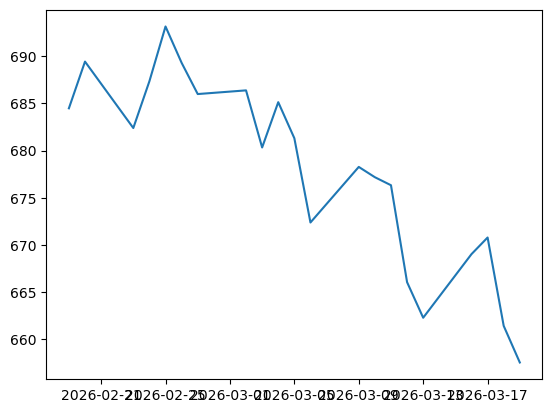

In [25]:
plt.plot(df['Close'])

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TSLA']: TypeError("'NoneType' object is not subscriptable")


Text(0.5, 1.0, 'TSLA Close vs Moving Average')

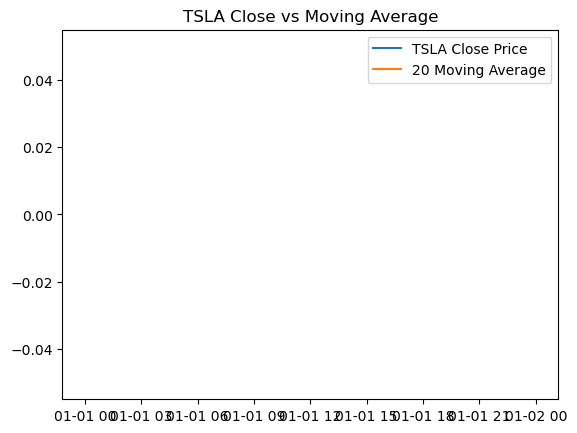

In [48]:
TICKER = 'TSLA'
WINDOW = 20

df = yf.download(TICKER, start='2020-01-01')
df['MA'] = df['Close'].rolling(WINDOW).mean()

plt.plot(df['Close'])
plt.plot(df['MA'])
plt.legend([f'{TICKER} Close Price',f'{WINDOW} Moving Average'])
plt.title(f'{TICKER} Close vs Moving Average')


In [49]:
df.dropna(inplace=True)
import numpy as np

In [50]:
df.columns = df.columns.get_level_values(0)

def add_ma_strategy(df):
    df['Strategy'] = np.where(df['Close'] > df['MA'],1,-1)
    return df
df = add_ma_strategy(df)
df

Price,Adj Close,Close,High,Low,Open,Volume,MA,Strategy
Date,,,,,,,,


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,MA,Strategy,asset_cumulative,strategy_cumulative
Date,,,,,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500,NaN,NaN,NaN,NaN
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500,NaN,-1.0,0.029633,-0.029633
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000,NaN,-1.0,0.049458,-0.048317
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500,NaN,-1.0,0.090178,-0.085243
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500,NaN,-1.0,0.143820,-0.130254
...,...,...,...,...,...,...,...,...,...
2026-03-13,391.200012,400.200012,389.950012,399.170013,58504100,404.827000,-1.0,12.638266,4.445083
2026-03-16,395.559998,403.730011,394.420013,396.220001,58068300,403.733000,-1.0,12.790266,4.384397
2026-03-17,399.269989,400.119995,393.000000,395.690002,46890500,403.164999,-1.0,12.919606,4.333896


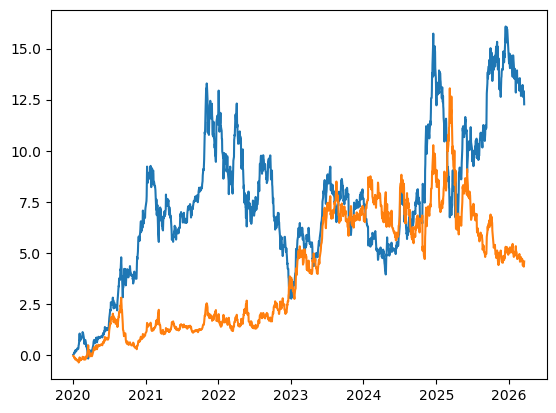

In [51]:
def get_data():
    df = yf.download(TICKER, start='2020-01-01')
    df.columns = df.columns.get_level_values(0)

    df['MA'] = df['Close'].rolling(WINDOW).mean()
    return df
    

def add_strategy(df):
    df.columns = df.columns.get_level_values(0)
    df['Strategy'] = np.where(df['Close'] > df['MA'],1,-1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df

def test_strategy(df):
    df['asset_cumulative'] = np.cumprod(1+ df['Close'].pct_change()) - 1
    df['strategy_cumulative'] = np.cumprod(1+ df['Close'].pct_change() * df['Strategy']) - 1

    plt.plot(df['asset_cumulative'])
    plt.plot(df['strategy_cumulative'])
    return df

def main():
    df = get_data()
    df = add_strategy(df)
    df = test_strategy(df)
    return df

main()